In [32]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib import cm
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D    
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.colors import ListedColormap

In [23]:
folder_path = 'experiments/amoc_experiments/'
amoc_files = glob.glob(os.path.join(folder_path, '*.csv'))
bifurcation_list=[]
for file in amoc_files:
    if file.startswith('experiments/amoc_experiments/bifurcation'):
        bifurcation = pd.read_csv(file)
        bifurcation_list.append(bifurcation)
bifurcation_df = pd.concat(bifurcation_list,ignore_index=True)

In [24]:
one_traj=bifurcation_df.loc[bifurcation_df['Label']==148]
one_traj['sigma'] = one_traj['sigma'].astype(str)  # make categorical
sns.set_palette('plasma')

/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_6631/2219827270.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_traj['sigma'] = one_traj['sigma'].astype(str)  # make categorical


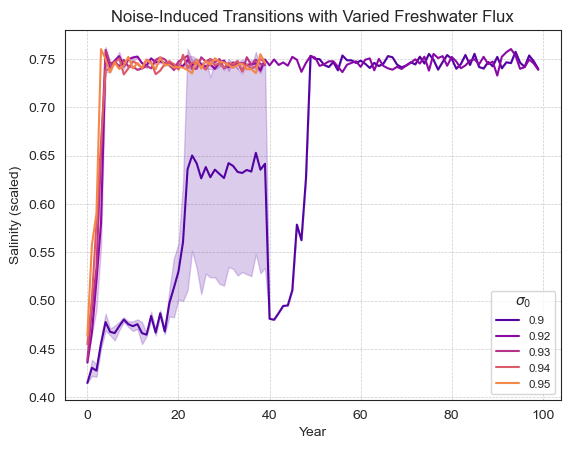

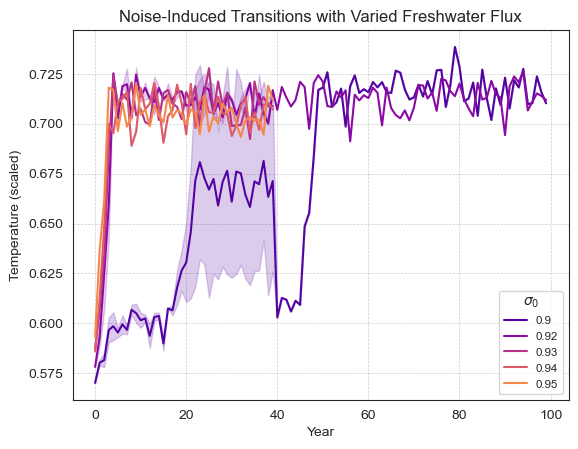

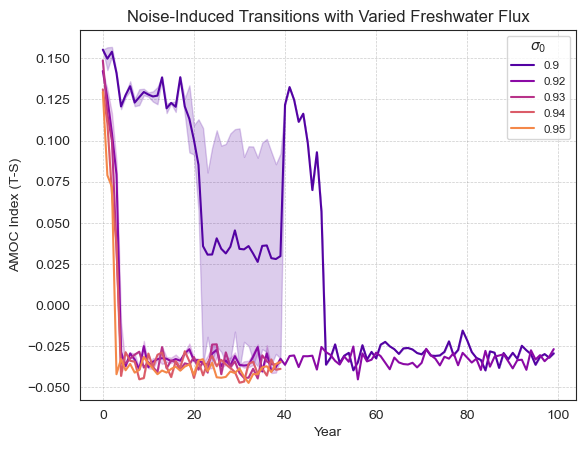

In [25]:

plt.figure()
sns.lineplot(data=one_traj,x='Run name',y='Corresponding S Value',hue='sigma')
legend = plt.legend(title=r'$\sigma_0$',fontsize='small', fancybox=True)
plt.xlabel('Year')
plt.ylabel('Salinity (scaled)')
plt.title('Noise-Induced Transitions with Varied Freshwater Flux')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
plt.savefig("sigma_varied_timeseries_salinity.png")

plt.figure()
sns.lineplot(data=one_traj,x='Run name',y='Corresponding T value',hue='sigma')
legend = plt.legend(title=r'$\sigma_0$',fontsize='small', fancybox=True)
plt.xlabel('Year')
plt.ylabel('Temperature (scaled)')

plt.title('Noise-Induced Transitions with Varied Freshwater Flux')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
plt.savefig("sigma_varied_timeseries_temp.png")

plt.figure()
sns.lineplot(data=one_traj,x='Run name',y='Last AMOC value',hue='sigma')
legend = plt.legend(title=r'$\sigma_0$',fontsize='small', fancybox=True)
plt.xlabel('Year')
plt.ylabel('AMOC Index (T-S)')

plt.title('Noise-Induced Transitions with Varied Freshwater Flux')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
plt.savefig("sigma_varied_timeseries_amoc.png")

/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_6631/1850260132.py:3: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(data=one_traj,x='Corresponding S Value',y='Corresponding T value',hue='sigma',palette=colors)


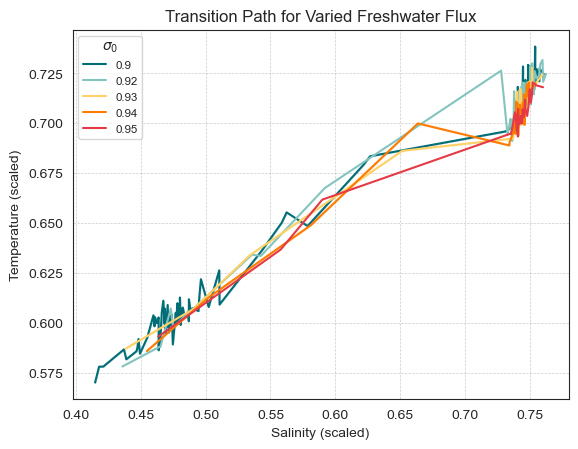

In [26]:
plt.figure()
colors = ['#006d77', '#83c5be', '#ffd166', '#ff7b00', '#e63946', '#457b9d']
sns.lineplot(data=one_traj,x='Corresponding S Value',y='Corresponding T value',hue='sigma',palette=colors)
legend = plt.legend(title=r'$\sigma_0$',fontsize='small', fancybox=True)
plt.xlabel('Salinity (scaled)')
plt.ylabel('Temperature (scaled)')

plt.title('Transition Path for Varied Freshwater Flux')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
plt.savefig("sigma_varied_transition_path.png")

In [27]:
#import all salts and amocs, concat
folder_path = 'experiments/degeneracy/amocs/yearly'
amoc_files = glob.glob(os.path.join(folder_path, '*.csv'))
amoc_list=[]
for file in amoc_files:
     #load files
    amocs = pd.read_csv(file)
    amoc_list.append(amocs)

folder_salt = 'experiments/degeneracy/salts/yearly'
salt_files = glob.glob(os.path.join(folder_salt, '*.csv'))
salt_list=[]
for file in salt_files:
     #load files
    salts = pd.read_csv(file)
    salt_list.append(salts)
    

In [28]:
amoc_df = pd.concat(amoc_list, ignore_index=True)
salt_df = pd.concat(salt_list, ignore_index=True)

In [29]:
salt_df.head()

,"Initial S,T",Last AMOC value,Corresponding T value,Corresponding S Value,Corresponding x value,Corresponding y value,Corresponding z value,Label,Exponential,Weight,...,Killed?,Init Label,Agg Label,Initial Temperatures Next Block,Initial Salinities Next Block,Initial x Next Block,Initial y Next Block,Initial z Next Block,Run name,k
0,"0.9892785759876525,0.0083603986747423,2.116058...",0.154706,0.565592,0.410886,1.717410,0.508731,-0.010266,0,2.442311e-26,4.706807e-85,...,1.0,155,0,0.584920,0.432856,1.350304,0.709658,-1.071307,0,7000
1,"1.6717879374303208,-1.0718178369130131,0.28189...",0.148399,0.575645,0.427246,1.214823,-0.646712,-0.176817,1,2.833710e+21,5.461108e-38,...,1.0,82,1,0.587943,0.435800,2.329449,0.982457,0.962087,0,7000
2,"0.9689360709817024,0.1097040615751266,1.657646...",0.145695,0.572767,0.427072,1.320996,-0.351530,-0.517079,2,7.157410e-01,1.379371e-59,...,1.0,82,2,0.587943,0.435798,2.329449,0.982457,0.962087,0,7000
3,"0.5840736729946078,-0.9406394494557266,1.09735...",0.154444,0.565476,0.411032,0.586494,1.687736,-1.083897,3,3.284890e-17,6.330620e-76,...,1.0,82,3,0.587943,0.435800,2.329449,0.982457,0.962087,0,7000
4,"1.3895125163471622,0.0304907312824446,-0.78560...",0.147139,0.579648,0.432509,1.330993,0.575348,-1.163130,4,4.591728e+11,8.849149e-48,...,1.0,82,4,0.587943,0.435802,2.329449,0.982457,0.962087,0,7000


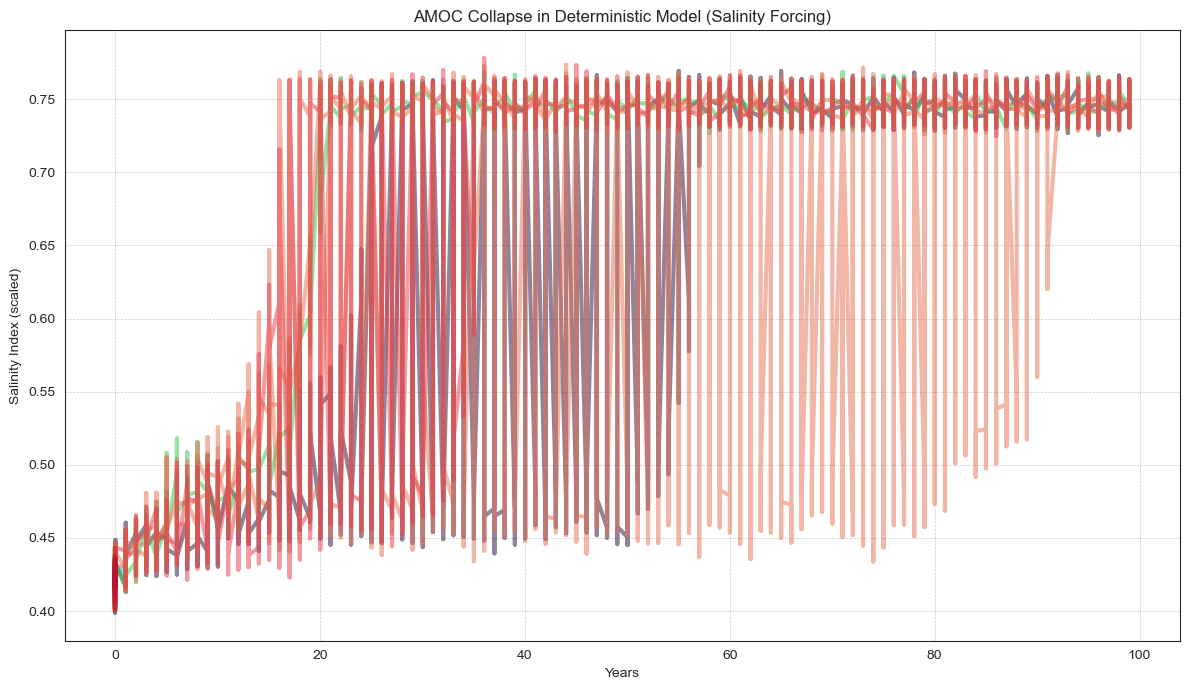

In [60]:
fig, ax = plt.subplots(figsize=(12, 7))

palette = [
    "#240B36",  # deep purple
    "#5E239D",  # violet
    "#3A86FF",  # bright blue
    "#00B4D8",  # cyan
    "#00A896",  # teal
    "#2DC653",  # bright green
    "#A7C957",  # yellow-green
    "#FFD166",  # gold
    "#FF9F1C",  # orange
    "#FF6D00",  # vivid orange
    "#E76F51",  # coral-red
    "#E63946",  # red
    "#B5172E",  # deep red
]

cmap = ListedColormap(palette)

# Use a categorical colormap: one distinct color per original ancestor
ancestors = salt_df["Agg Label"].unique()

colors = cmap(np.linspace(0, 1, len(ancestors)))


for color, (ancestor, group) in zip(colors, salt_df.groupby("Agg Label")):
    group = group.sort_values("Run name")

    ax.plot(
        group["Run name"],
        group["Corresponding S Value"],
        color=color,
        markersize=3.5,
        markeredgecolor="white",
        linewidth=3,
        alpha=0.5,
        label=f"Ancestor {ancestor}",
        zorder=2,
    )
ax.set_ylabel("Salinity Index (scaled)")
ax.set_xlabel("Years")
ax.set_title("AMOC Collapse in Deterministic Model (Salinity Forcing)")

plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)


fig.tight_layout()
#plt.show()
plt.savefig("ancestors_fixed_salinity.png")



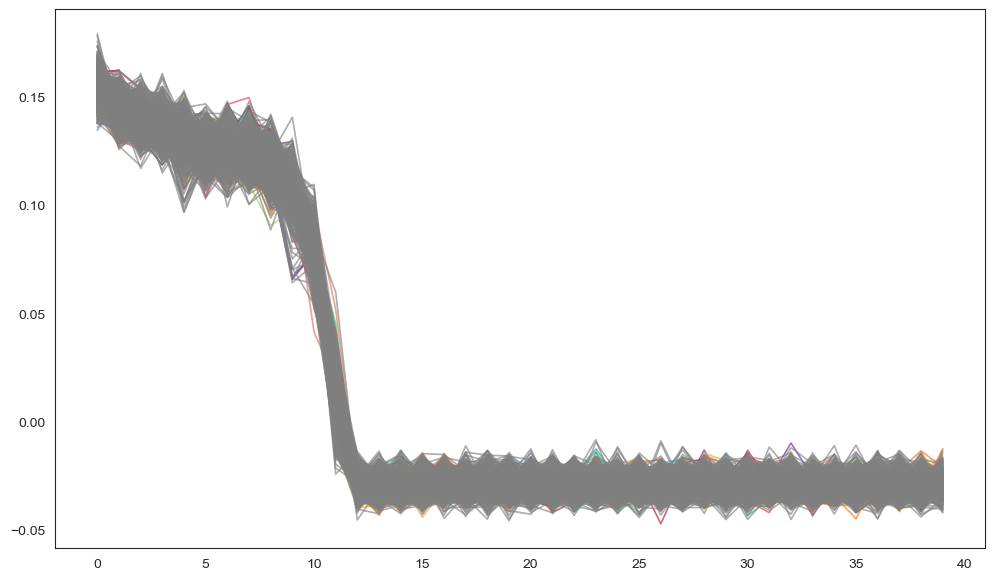

In [52]:
fig, ax = plt.subplots(figsize=(12, 7))

# Assign one color to each parent/ancestor
parents = amoc_df["Agg Label"].dropna().unique()
colors = cmap(np.linspace(0, 1, len(parents)))

parent_colors = dict(zip(parents, colors))

# Plot every trajectory independently
for traj_id, traj in df.groupby("Label", sort=False):
    traj = traj.sort_values("Run name")

    # Use the trajectory's parent/ancestor for its color
    parent = traj["Agg Label"].dropna().iloc[0] \
        if traj["Agg Label"].notna().any() else traj_id

    color = parent_colors.get(parent, "gray")

    ax.plot(
        traj["Run name"],
        traj["Last AMOC value"],
        color=color,
        linewidth=1.2,
        alpha=0.65,
        zorder=2,
    )


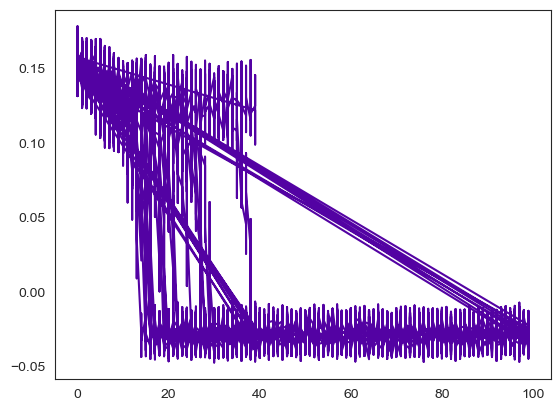

In [31]:
plt.plot(amoc_df['Run name'],amoc_df['Last AMOC value'])

NameError: name 'salt_df' is not defined

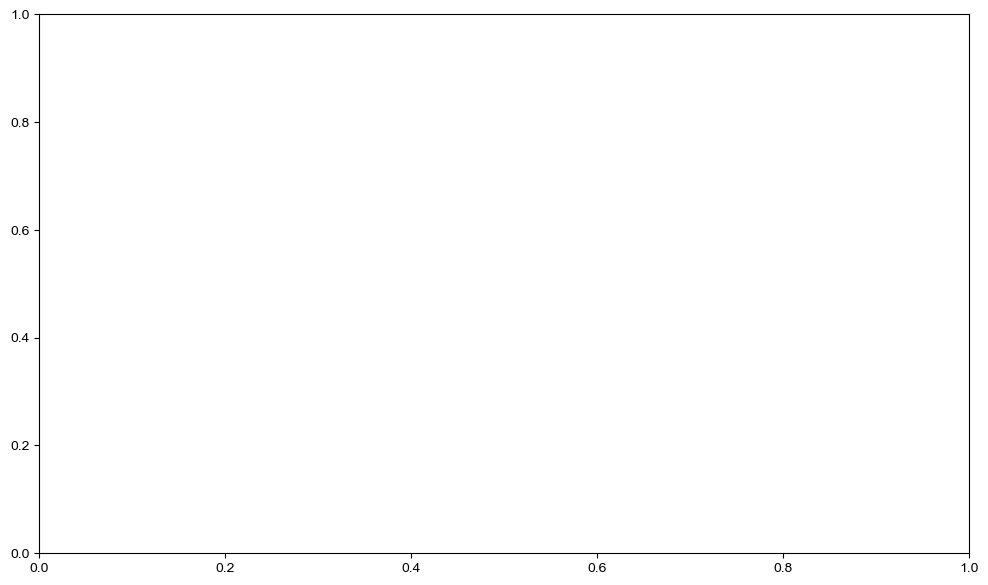

In [21]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.set_style("white")
# Use a categorical colormap: one distinct color per original ancestor
ancestors = salt_df["Agg Label"].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(ancestors)))

for color, (ancestor, group) in zip(colors, amoc_df.groupby("Agg Label")):
    group = group.sort_values("Run name")
    
    ax.plot(
        group["Run name"],
        group["Corresponding S Value"],
        color=color,

        linewidth=1,
        alpha=0.5,
        label=f"Ancestor {ancestor}",
        zorder=2,
        marker=".",
        markersize=2
    )

# Major and minor grid lines
ax.minorticks_on()
ax.grid(True, which="major", color="gray", linestyle="-", linewidth=0.7, alpha=0.45)
ax.grid(True, which="minor", color="gray", linestyle=":", linewidth=0.5, alpha=0.25)

ax.set_ylabel("Salinity Index (scaled)")
ax.set_xlabel("Years")
ax.set_title("AMOC Collapse From Salinity Forcing")



fig.tight_layout()
plt.show()



In [3]:
edge_control=pd.read_csv('experiments/edge/100_traj.csv')
edge_state= pd.read_csv('experiments/edge/edge_states.csv')

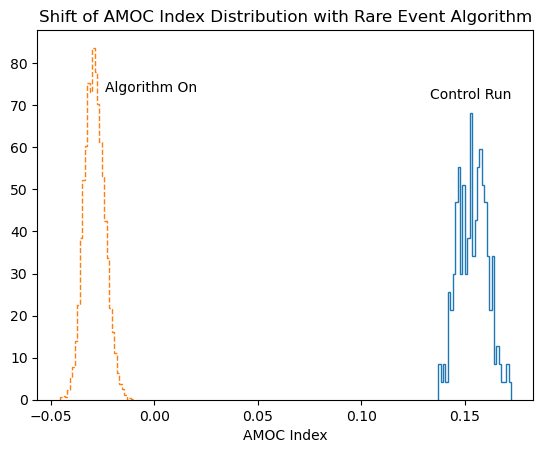

In [7]:
'''
Histogram showing shift of distribution
'''
def get_initials():
    
    #control run initial parameterization
    control_run = pd.read_csv('experiments/control_runs/control_run0505.csv')
    #remove transient
    control_dropped = control_run.loc[control_run['t']>=10]
    #access every 5th row (time unit)
    control_5th = control_dropped.iloc[::500]
    control_5th.head()
    cols = ['x','y','z','T', 'S']
    x_list, y_list, z_list, temp_list, salt_list = [control_5th[c].tolist() for c in cols]

    return x_list,y_list,z_list,temp_list,salt_list
    
#plot distribution change between RE algorithm and initial simulation
x_list,y_list,z_list,temp_list,salt_list = get_initials()
amoc_list = []
for temp in range(len(temp_list)):
    amoc_val = temp_list[temp] - salt_list[temp]
    amoc_list.append(amoc_val)

metadata_500 = pd.read_csv('experiments/amoc_experiments/useful_transitions/metadata_trans_off_40y_200traj_-500k.csv')
metadata_shifted = metadata_500.loc[metadata_500['Run name']>20]
RE_list = metadata_shifted['Last AMOC value'].tolist()

plt.figure()
counts1, bins1, _ = plt.hist(amoc_list, bins=30, density=True, histtype='step', linestyle='-')
mid1 = (bins1[:-1] + bins1[1:]) / 2
peak_x1 = mid1[np.argmax(counts1)]
peak_y1 = max(counts1)
plt.text(peak_x1, peak_y1 + peak_y1*0.05, "Control Run", ha='center')
counts2, bins2, _ = plt.hist(RE_list, bins=30, density=True, histtype='step',linestyle='--')
mid2 = (bins2[:-1] + bins2[1:]) / 2
peak_x2 = mid2[np.argmax(counts2)]
peak_y2 = max(counts2)
plt.text(peak_x2*0.8, peak_y2 + peak_y2*-0.125, "Algorithm On", ha='left')
plt.xlabel("AMOC Index")
plt.title("Shift of AMOC Index Distribution with Rare Event Algorithm")
#plt.show()
plt.savefig("hist_shifted_values.png")

In [4]:

folder_path = 'experiments/salt_experiments/useful_transitions/'
for file in os.listdir(folder_path):

        #get variables from file name
    name = file.replace(".csv", "")
    _,  years, traj, seed = name.split("_")

    years = int(years.replace("y", ""))
    traj  = int(traj.replace("traj", ""))
    seed  = int(seed.replace("k", ""))

    #load files
    comp_df = pd.read_csv(salts[file])
    re_df = pd.read_csv(re_list[file])
    #save value of final trajectory
    ancestor=re_df['Agg Label'].iloc[-1]

    #filter all data
    initial_salts=comp_df.loc[(comp_df['t']==0) & (comp_df['Run name']==0)]
    initial_salts.head(400)

    #T vs S
    fig = plt.figure()
    ax = fig.add_subplot(111)
    colors=initial_salts.index
    ax.scatter(
        initial_salts['T'],    # y
        initial_salts['S'], # z
        c=colors,       # color by index
        cmap='viridis'  # choose a colormap
    )
    point = initial_salts.iloc[ancestor]
    # add text near the point
    ax.text(
        point['T'], 
        point['S'],
        ancestor,           # the label
        fontsize=10, 
        color='red'
    )
    ax.set_xlabel('T')
    ax.set_ylabel('S')
    plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
    
    plt.show()
    
    #x vs y
    fig = plt.figure()
    ax = fig.add_subplot(111)
    colors=initial_salts.index
    ax.scatter(
        initial_salts['x'],    # y
        initial_salts['y'], # z
        c=colors,       # color by index
        cmap='viridis'  # choose a colormap
    )
    point = initial_salts.iloc[ancestor]
    # add text near the point
    ax.text(
        point['x'], 
        point['y'],
        ancestor,           # the label
        fontsize=10, 
        color='red'
    )
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
    
    plt.show()
    
    #y vs z
    fig = plt.figure()
    ax = fig.add_subplot(111)
    colors=initial_salts.index
    ax.scatter(
        initial_salts['y'],    # y
        initial_salts['z'], # z
        c=colors,       # color by index
        cmap='viridis'  # choose a colormap
    )
    point = initial_salts.iloc[ancestor]
    # add text near the point
    ax.text(
        point['y'], 
        point['z'],
        ancestor,           # the label
        fontsize=10, 
        color='red'
    )
    ax.set_xlabel('y')
    ax.set_ylabel('z')
    plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
    
    plt.show()

NameError: name 'salts' is not defined

In [ ]:
#T vs S
fig = plt.figure()
ax = fig.add_subplot(111)
colors=initial_salts.index
ax.scatter(
    initial_salts['T'],    # y
    initial_salts['S'], # z
    c=colors,       # color by index
    cmap='viridis'  # choose a colormap
)
point = initial_salts.iloc[148]
# add text near the point
ax.text(
    point['T'], 
    point['S'],
    '148',           # the label
    fontsize=10, 
    color='red'
)
ax.set_xlabel('T')
ax.set_ylabel('S')

plt.show()

#x vs y
fig = plt.figure()
ax = fig.add_subplot(111)
colors=initial_salts.index
ax.scatter(
    initial_salts['T'],    # y
    initial_salts['S'], # z
    c=colors,       # color by index
    cmap='viridis'  # choose a colormap
)
point = initial_salts.iloc[148]
# add text near the point
ax.text(
    point['T'], 
    point['S'],
    '148',           # the label
    fontsize=10, 
    color='red'
)
ax.set_xlabel('T')
ax.set_ylabel('S')

plt.show()

#y vs z
fig = plt.figure()
ax = fig.add_subplot(111)
colors=initial_salts.index
ax.scatter(
    initial_salts['T'],    # y
    initial_salts['S'], # z
    c=colors,       # color by index
    cmap='viridis'  # choose a colormap
)
point = initial_salts.iloc[148]
# add text near the point
ax.text(
    point['T'], 
    point['S'],
    '148',           # the label
    fontsize=10, 
    color='red'
)
ax.set_xlabel('T')
ax.set_ylabel('S')

plt.show()

In [ ]:
'''
Lineplots of Trajectory shifts
'''
shifted_dfs = []
ks = []
folder_path='salts/'
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print(file)
        

        #get variables from file name
        name = file.replace(".csv", "")
        _,  years, traj, seed = name.split("_")

        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))

        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)

        #get ks in list
        ks.append(seed)

        plt.figure()
        #Lineplot
        sns.set_style("darkgrid")
        sns.lineplot(
            data=df,
            x="Run name",
            y="Corresponding S Value",
            hue="Agg Label",
            units="Label",   #forces 200 individual lines
            estimator=None,          #prevents averaging / collapsing
            lw=1,
            palette=sns.color_palette("Spectral", n_colors=df["Agg Label"].nunique()),
            legend=False)

        plt.title(f"AMOC RE Sampling with {years} years, {traj} trajectories, k={seed}")
        plt.xlabel("time")
        plt.ylabel("AMOC Index")

        
       # plt.savefig(f"amoc_lineplot_{years}year_{traj}traj_{seed}k.png")
        plt.savefig(f"amoc_lineplot_{years}year_{traj}traj_{seed}k.png")
        #Barcode plot
        pivot = df.pivot(index='Label', columns='Run name', values='Agg Label')

        plt.figure()
        sns.heatmap(pivot, cmap="tab20", cbar=False)
        plt.xlabel("time")
        plt.ylabel("Trajectory")
        plt.title(f"Lineage for Salinity over {years} years, k= {seed}")
        #plt.show()
        #plt.close()
        #plt.savefig(f"salinity_barcode_{years}year_{traj}traj_{seed}k.png")

        #muller plot
        counts = df.groupby(['Run name', 'Agg Label']).size().reset_index(name='count')
        pivot = counts.pivot(index='Run name', columns='Agg Label', values='count').fillna(0)
        
        pivot.plot.area(alpha=0.8)
        plt.legend([],[], frameon=False)
        plt.title(f"Ancestors for {traj} trajectories, {years} years, {seed} k")
        plt.xlabel("Run")
        plt.ylabel("Trajectory ID")
        plt.show()

        plt.close()
'''
       # plt.show()
        #plt.close()
        #plt.savefig(f"lineplot_{years}year_{traj}traj_{seed}k.png")

        plt.figure()
        #plt.hist(control_sample['AMOC'])
        plt.hist(df['Corresponding S Value'])
        plt.title(f"Distribution of AMOC indices during RE Sampling over {years} years")
        plt.xlabel("Temperature (K)")
        #plt.show()
        #plt.close()

'''

In [ ]:
salt_trans = pd.read_csv('salts/salt_40y_1000traj_8000k.csv')
amoc_trans = pd.read_csv('exp_names_shifted/metadata_trans_off1st_40y_1000traj_-1000k.csv')

In [9]:
edge_state.head()

,t,x,y,z,T,S,atmosphere
0,0.000000,0.000253,0.000053,0.000295,1.500000,0.960205,1.534042e-07
1,0.000008,0.051025,0.024751,0.000330,1.499908,0.960168,3.216248e-03
2,0.000015,0.101450,0.048899,0.000611,1.499817,0.960132,1.268362e-02
3,0.000023,0.151503,0.072562,0.001369,1.499727,0.960095,2.822041e-02
4,0.000030,0.201160,0.095794,0.002822,1.499638,0.960059,4.964977e-02


<Axes: xlabel='t', ylabel='S'>

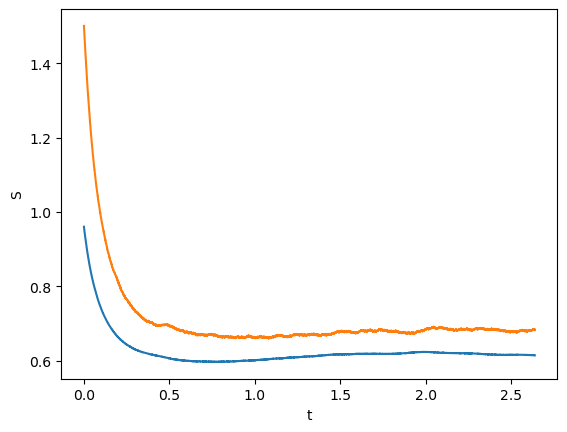

In [5]:
edge_converged=edge_state.loc[edge_state['t']>0.5]
#edge_control['AMOC'] = edge_control['T']-edge_control['S']
#edge_control.head()
sns.lineplot(data=edge_state,x='t',y='S')
sns.lineplot(data=edge_state,x='t',y='T')

In [6]:
edge_control.head()
edge_control['atmosphere']=(edge_control['Corresponding x value']**2+edge_control['Corresponding y value']**2
                            + edge_control['Corresponding z value']**2)
edge_cut=edge_control.loc[edge_control['Run name']>10]
edge_converged=edge_state.loc[edge_state['t']>0.5]

In [7]:
edge_state.head()
edge_converged['atmosphere']=(edge_converged['x']**2+edge_converged['y']**2
                            + edge_converged['z']**2)

/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_6631/313271600.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  edge_converged['atmosphere']=(edge_converged['x']**2+edge_converged['y']**2


In [8]:
det_path = pd.read_csv('experiments/salt_experiments/useful_transitions/salt_40y_200traj_7000k.csv')
det_traj = det_path.loc[det_path['Label']==148]
det_traj.head(50)
#det_traj.head()

,"Initial S,T",Last AMOC value,Corresponding T value,Corresponding S Value,Corresponding x value,Corresponding y value,Corresponding z value,Label,Exponential,Weight,...,Killed?,Init Label,Agg Label,Initial Temperatures Next Block,Initial Salinities Next Block,Initial x Next Block,Initial y Next Block,Initial z Next Block,Run name,k
148,"1.921745810551503,-1.8552472312704615,0.576367...",0.138956,0.582608,0.443652,0.600735,0.433588,1.461497,148,6.203252e+56,3.701509e+01,...,0.0,148,148,0.582608,0.443652,0.600735,0.433588,1.461497,0,7000
348,"0.6007353646568261,0.43358828606252675,1.46149...",0.141876,0.576852,0.434975,1.092410,-0.504939,-0.655787,148,1.224761e+11,2.550284e-25,...,1.0,121,148,0.595585,0.449358,1.196652,0.052041,-0.605420,1,7000
548,"1.1966517347272834,0.05204100830360289,-0.6054...",0.135495,0.574879,0.439383,1.107972,-0.656356,0.319315,148,3.285759e-06,9.617222e-41,...,1.0,1,148,0.581795,0.442808,2.055740,-0.831880,-0.389214,2,7000
748,"2.0557402218169614,-0.8318796487204368,-0.3892...",0.148149,0.583261,0.435112,1.462519,0.018151,1.233848,148,4.110676e-10,9.573580e-32,...,1.0,102,148,0.589351,0.447443,1.383572,0.972893,0.792128,3,7000
948,"1.3835723204579944,0.9728932478689418,0.792127...",0.140015,0.581000,0.440985,0.874141,-0.782446,0.341923,148,4.246906e+02,3.261846e-29,...,1.0,8,148,0.589104,0.459774,0.870119,0.078466,1.241880,4,7000
1148,"0.870118522112864,0.07846629257371313,1.241880...",0.138999,0.585858,0.446859,0.714253,-1.110595,0.039115,148,1.373907e-01,1.847309e-26,...,1.0,131,148,0.596048,0.465375,0.688378,-0.489583,0.653163,5,7000
1348,"0.6883777231553407,-0.489582951931294,0.653162...",0.136636,0.594733,0.458098,0.077795,0.371669,1.399027,148,9.749447e+08,1.057561e-26,...,1.0,124,148,0.599341,0.465283,1.315660,0.136403,1.276560,6,7000
1548,"1.3156600252182271,0.13640342686884516,1.27655...",0.138005,0.593812,0.455806,0.274195,1.217893,-0.716628,148,1.372146e+06,1.146119e-20,...,1.0,53,148,0.598937,0.468515,0.765820,-1.203660,0.401505,7,7000
1748,"0.7658204768090239,-1.2036603217825232,0.40150...",0.157990,0.599610,0.441620,1.396648,0.120806,-1.186032,148,3.677400e-09,8.881267e-49,...,1.0,166,148,0.598879,0.471737,0.395217,0.923600,0.871570,8,7000
1948,"0.39521738631783226,0.9235998379175422,0.87156...",0.131050,0.593030,0.461980,0.939917,0.208797,-0.783707,148,2.623752e+07,2.005153e-26,...,1.0,52,148,0.604504,0.472393,-0.135930,0.407739,-0.783458,9,7000


In [9]:
instanton_back = pd.read_csv('experiments/edge/instanton_path_back_0.9.csv')
instanton = pd.read_csv('experiments/edge/instanton_path.csv')

In [10]:
instanton_back.head()

,T,S
0,0.750000,0.790000
1,0.745266,0.787133
2,0.740533,0.784266
3,0.735799,0.781399
4,0.731066,0.778533


/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_6631/290054796.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')
/var/folders/v1/ymptnwwx3x1b7_mw0nns09wr0000gn/T/ipykernel_6631/290054796.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  det_traj['atmosphere']=(det_traj['Corresponding x value']**2 + det_traj['Corresponding y value']**2 +


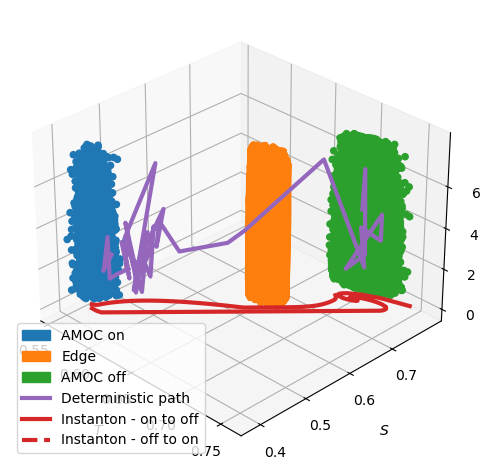

In [11]:
#make 3D plot of edge, AMOC on, AMOC off with T,S, and atmosphere combined variable
atmosphere_list = [0.2] * len(instanton)
T= np.concatenate([np.array(edge_converged['T']),np.array(edge_cut['Corresponding T value'])])
S= np.concatenate([np.array(edge_converged['S']),np.array(edge_cut['Corresponding S Value'])])
atmosphere= np.concatenate([np.array(edge_converged['atmosphere']),np.array(edge_cut['atmosphere'])])

cmap = cm.get_cmap('plasma')
color1 = cmap(0.)  # for condition 1
color2 = cmap(0.4)  # for condition 2
color3 = cmap(0.6)  # for condition 3
color_line1 = cmap(0.9)
color_line2 = cmap(0.8)
color1='#1f77b4'
color2='#ff7f0e'
color3='#2ca02c'
color_line1='#d62728'
color_line2='#9467bd'
colors=[]

for t, s in zip(T, S):
    if t < 0.65 and s < 0.5:
        colors.append(color1)
    elif t >= 0.65 and s < 0.71:
        colors.append(color2)
    else:
        colors.append(color3)


fig2 = plt.figure()

#surf4=ax2.plot(det_traj['Corresponding T value'],det_traj['Corresponding S Value'],det_traj['atmosphere'],color=)
ax2  = fig2.add_subplot(111, projection='3d')
surf2 = ax2.scatter(T, S, atmosphere,
                        color=colors,depthshade=False,)
surf3=ax2.plot(instanton['T'],instanton['S'],atmosphere_list,color=color_line1,
               linewidth=3, zorder=10, label='Instanton - on to off')
surf3=ax2.plot(instanton_back['T'],instanton_back['S'],color=color_line1,
               linewidth=3, zorder=12, label='Instanton - off to on')
det_traj['atmosphere']=(det_traj['Corresponding x value']**2 + det_traj['Corresponding y value']**2 + 
                        det_traj['Corresponding z value']**2)
surf4=ax2.plot(det_traj['Corresponding T value'],det_traj['Corresponding S Value'],det_traj['atmosphere'],
               color=color_line2, linewidth=3, zorder=11, label='Deterministic trajectory')

ax2.set_xlabel('$T$',labelpad=10)
ax2.set_ylabel('$S$',labelpad=10)
ax2.set_zlabel('$X^2+Y^2+Z^2$',rotation=90)
ax2.set_xticks([0.75, 0.7, 0.65,0.6,0.55])
ax2.set_yticks([0.4, 0.5, 0.6,0.7])
ax2.set_zticks([0, 2, 4,6])


patch1 = mpatches.Patch(color=color1, label='AMOC on')
patch2 = mpatches.Patch(color=color2, label='Edge')
patch3 = mpatches.Patch(color=color3, label='AMOC off')
line1_handle = mlines.Line2D([], [], color=color_line2, linewidth=3, label='Deterministic path')
line2_handle = mlines.Line2D([], [], color=color_line1, linewidth=3, label='Instanton - on to off')
line3_handle = mlines.Line2D([], [], color=color_line1, linewidth=3, linestyle='--', label='Instanton - off to on')
ax2.legend(handles=[patch1, patch2, patch3, line1_handle, line2_handle, line3_handle])

ax2.view_init(elev=30, azim=-45)
plt.tight_layout()
#plt.show()
#plt.savefig("3D_edge.png")
plt.savefig("3D_edge_inst_det.png")

In [12]:
instanton=pd.read_csv('experiments/edge/instanton_path.csv')

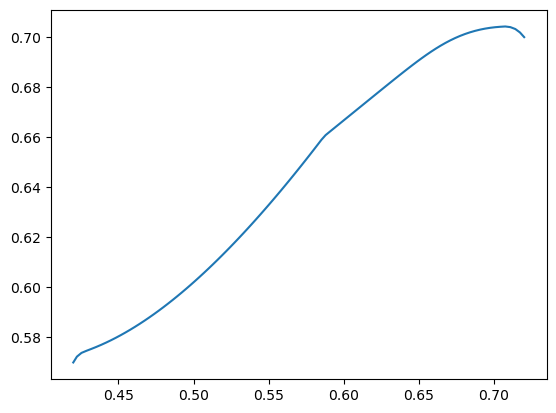

In [13]:
plt.plot(instanton['S'],instanton['T'])

In [ ]:
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
folder_path='experiments/amoc_experiments/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print(file)
        #get transition time periods
        year_col = 'Run name'   
        
        #get variables from file name
        name = file.replace(".csv", "")
        _, _, _, years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)


    plt.figure()
    
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding S Value'], df['Corresponding T value'],
            color="#d9d9d9", linewidth=1.0, zorder=2)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding S Value'], df['Corresponding T value'],
                    c=df['Run name'], cmap='plasma', s=40, zorder=3)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')


    ax.scatter(edge_converged['S'], edge_converged['T'],
               facecolor='#2b2b2b', edgecolor='#2b2b2b',marker='o', s=40, linewidth=0.05,
               label='edge state', zorder=6)

    ax.scatter(instanton['S'],instanton['T'],facecolor='#006d77',edgecolor='#006d77',marker='o',s=25,
               label='Instanton - on to off',zorder=5)
    #ax.scatter(instanton_back['S'],instanton_back['T'],facecolor='#2b2b2b',edgecolor='#2b2b2b',
              # s=25,label='Instanton - off to on',zorder=6)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    
    plt.title(f"Transition Path and Edge State (AMOC Forcing)")
    plt.xlabel('Salinity')
    plt.ylabel('Temperature')
    ax.legend()

    if (file=='metadata_trans_off1st_40y_200traj_-2000k.csv'):
       plt.savefig(f"edge_instanton_amoc_{traj}{seed}.png")
    #plt.show()
    #plt.close()

In [ ]:
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
amoc_transp = {"metadata_trans_off1st_40y_200traj_-2000k.csv": {"start": 24, "end": 27},
               "metadata_trans_off_40y_200traj_-500k.csv": {"start": 12, "end": 15},
               "metadata_trans_off1st_40y_1000traj_-500k.csv": {"start": 7, "end": 9}, 
               "metadata_trans_off1st_40y_200traj_-1000k.csv": {"start": 20, "end": 23},
               "metadata_trans_off1st_40y_1000traj_-2000k.csv": {"start": 9, "end": 11}, 
               "metadata_trans_off1st_40y_1000traj_-1000k.csv": {"start": 7, "end": 10}}
folder_path='exp_names_shifted/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    print(file)
    

    #get variables from file name
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        _,_,_,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)

        #get transition time periods
        start = amoc_transp[file]['start']
        end   = amoc_transp[file]['end']
        year_col = 'Run name'  

        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

        
    plt.figure()
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding S Value'], df['Corresponding T value'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding S Value'], df['Corresponding T value'],
                    c=df['Run name'], cmap='plasma', s=40, edgecolors='none', zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    ax.scatter(edge_converged['S'], edge_converged['T'],
               color='#2b2b2b', edgecolor='#2b2b2b',marker='o', s=40, linewidth=1.2,
               label='edge state', zorder=6)

        # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding S Value'], start_row['Corresponding T value']
    else:
        s_start = df.loc[start_mask, 'Corresponding S Value'].mean()
        t_start = df.loc[start_mask, 'Corresponding T value'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding S Value'], end_row['Corresponding T value']
    else:
        s_end = df.loc[end_mask, 'Corresponding S Value'].mean()
        t_end = df.loc[end_mask, 'Corresponding T value'].mean()

    # plot straight line between the two representative points
    ax.plot([s_start, s_end], [t_start, t_end],
            color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    plt.title(f"Transition Path and Edge State (AMOC Forcing)")
    plt.xlabel('Salinity')
    plt.ylabel('Temperature')
    ax.legend()
    
    
    '''#legend
    legend_elements = [
        Line2D([0], [0], marker='X', linestyle='None',
               label='AMOC', markersize=8,
                markerfacecolor=amoc_color,
                markeredgecolor=amoc_color,)
    ]
    '''
    plt.savefig(f"edge_instanton_amoc_{traj}{seed}.png")
    #plt.show()
    #plt.close()

In [ ]:
'''
the same plots again but salinity vs x^2+y^2+z^2, and temperature vs the same
'''
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
#dictionary of files and their transition periods
salt_transp = {"salt_40y_1000traj_8000k.csv": {"start": 10, "end": 12}, "salt_40y_1000traj_7000k.csv": {"start": 8, "end": 11},
               "salt_40y_1000traj_9000k.csv": {"start": 19, "end": 21}, "salt_40y_200traj_8000k.csv": {"start": 15, "end": 19},
               "salt_40y_200traj_7000k.csv": {"start": 28, "end": 31}, "salt_40y_200traj_9000k.csv": {"start": 27, "end": 29}}
#start = d["range"]["start"]; end = d["range"]["end"]
folder_path='salts/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        print(file)
        #get transition time periods
        start = salt_transp[file]['start']
        end   = salt_transp[file]['end']
        year_col = 'Run name'   
        
        #get variables from file name
        name = file.replace(".csv", "")
        _,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)
    
        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

        #make atmospheric column
        df['atmosphere'] = df['Corresponding x value']**2 + df['Corresponding y value']**2 + df['Corresponding z value']**2

    plt.figure()
    
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding S Value'], df['atmosphere'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding S Value'], df['atmosphere'],
                    c=df['Run name'], cmap='plasma', s=40, zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding S Value'], start_row['atmosphere']
    else:
        s_start = df.loc[start_mask, 'Corresponding S Value'].mean()
        t_start = df.loc[start_mask, 'atmosphere'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding S Value'], end_row['atmosphere']
    else:
        s_end = df.loc[end_mask, 'Corresponding S Value'].mean()
        t_end = df.loc[end_mask, 'atmosphere'].mean()

    #create atmosphere column for edge state
    edge_converged['atmosphere'] = edge_converged['x']**2 + edge_converged['y']**2 + edge_converged['z']**2
    ax.plot(edge_converged['S'], edge_converged['atmosphere'],alpha=0.5,label='edge state',color='#2b2b2b')
             #  facecolor='#2b2b2b', edgecolor='#2b2b2b',marker='o', s=40, linewidth=0.05,
            #   label='edge state', zorder=6, alpha=0.5)

    # plot straight line between the two representative points
    #ax.plot([s_start, s_end], [t_start, t_end],
            #color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    #ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    
    plt.title(f"Transition Path and Edge State (Salinity Forcing)")
    plt.xlabel('Salinity')
    plt.ylabel(r'$x^{2} + y^{2} + z^{2}$')
    ax.legend()

    if (file=='salt_40y_200traj_9000k.csv'):
        plt.savefig(f"edge_instanton_salinity_xyz_{traj}{seed}.png")
    #plt.show()
    #plt.close()

In [ ]:
#make 2D and 3D scatter plots to show AMOC on/off and salinity-driven transitions in one plot
amoc_transp = {"metadata_trans_off1st_40y_200traj_-2000k.csv": {"start": 24, "end": 27},
               "metadata_trans_off_40y_200traj_-500k.csv": {"start": 12, "end": 15},
               "metadata_trans_off1st_40y_1000traj_-500k.csv": {"start": 7, "end": 9}, 
               "metadata_trans_off1st_40y_200traj_-1000k.csv": {"start": 20, "end": 23},
               "metadata_trans_off1st_40y_1000traj_-2000k.csv": {"start": 9, "end": 11}, 
               "metadata_trans_off1st_40y_1000traj_-1000k.csv": {"start": 7, "end": 10}}
folder_path='exp_names_shifted/useful_transitions'
shifted_dfs=[]
ks=[]
for file in os.listdir(folder_path):
    print(file)
    

    #get variables from file name
    if file.endswith(".csv"):
        name = file.replace(".csv", "")
        _,_,_,  years, traj, seed = name.split("_")
    
        years = int(years.replace("y", ""))
        traj  = int(traj.replace("traj", ""))
        seed  = int(seed.replace("k", ""))
    
        df = pd.read_csv(os.path.join(folder_path, file))
        print(df['k'].unique())
        shifted_dfs.append(df)
    
        #get ks in list
        ks.append(seed)

        #get transition time periods
        start = amoc_transp[file]['start']
        end   = amoc_transp[file]['end']
        year_col = 'Run name'  

        # mask rows in the transition period
        start_mask = df[year_col] == start
        end_mask   = df[year_col] == end

        #make atmospheric column
        df['atmosphere'] = df['Corresponding x value']**2 + df['Corresponding y value']**2 + df['Corresponding z value']**2

    plt.figure()
    ax = plt.gca()
    # faint background line for context
    ax.plot(df['Corresponding T value'], df['atmosphere'],
            color="#d9d9d9", linewidth=1.0, zorder=1)
    
    # colored instanton / trajectory gradient by time (use a numeric column, e.g. Year)
    sc = ax.scatter(df['Corresponding T value'], df['atmosphere'],
                    c=df['Run name'], cmap='plasma', s=40, edgecolors='none', zorder=2)
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Year')

    edge_converged['atmosphere'] = edge_converged['x']**2 + edge_converged['y']**2 + edge_converged['z']**2
    ax.plot(edge_converged['T'], edge_converged['atmosphere'],label='edge state',
               color='#2b2b2b',alpha=0.5,zorder=3)
               #edgecolor='#2b2b2b',marker='o', s=40, linewidth=1.2,
               #label='edge state', zorder=6)

        # if exact years not present, use nearest
    if not start_mask.any():
        start_row = df.iloc[(df[year_col] - start).abs().argmin()]
        s_start, t_start = start_row['Corresponding T value'], start_row['atmosphere']
    else:
        s_start = df.loc[start_mask, 'Corresponding T value'].mean()
        t_start = df.loc[start_mask, 'atmosphere'].mean()
    
    if not end_mask.any():
        end_row = df.iloc[(df[year_col] - end).abs().argmin()]
        s_end, t_end = end_row['Corresponding T value'], end_row['atmosphere']
    else:
        s_end = df.loc[end_mask, 'Corresponding T value'].mean()
        t_end = df.loc[end_mask, 'atmosphere'].mean()

    # plot straight line between the two representative points
    #ax.plot([s_start, s_end], [t_start, t_end],
            #color='#006d77', linewidth=2.5, solid_capstyle='butt', zorder=4,label="transition")

    #ax.scatter([s_start, s_end], [t_start, t_end], marker='x',color='#004b57', s=40, zorder=5)
    
    # grid on
    ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
    plt.title(f"Transition Path and Edge State (AMOC Forcing)")
    plt.xlabel('Temperature')
    plt.ylabel(r'$x^{2} + y^{2} + z^{2}$')
    ax.legend()
    
    
    '''#legend
    legend_elements = [
        Line2D([0], [0], marker='X', linestyle='None',
               label='AMOC', markersize=8,
                markerfacecolor=amoc_color,
                markeredgecolor=amoc_color,)
    ]
    '''
    if (file=='metadata_trans_off1st_40y_200traj_-2000k.csv'):
        print('yes')
        plt.savefig(f"edge_instanton_amoc_xyz_{traj}{seed}.png")
    #plt.show()
    #plt.close()